# Amazon Product Reviews — Data Engineering Project
## Transformational AI | Big Data with Python & Jupyter
### PCEP Preparation — Data Analysis Pipeline

---
**Project Goal:** Download, explore, clean, and visualize Amazon product reviews and metadata to produce a curated `top_products` dataset for the Machine Learning team.

**Deliverables:**
- `top_products.csv` — cleaned dataset (rating ≥ 4.5, valid title, non-null price)
- `top_products.parquet` — same dataset in Parquet format
- `user_inputs.txt` — reflection answers
- This `.ipynb` notebook with all cell outputs


---
## Part 1: Preparing the Environment

### Part 1.1: Python & Jupyter Versions


In [1]:
# Verify Python and Jupyter versions
import sys
print(f"Python version: {sys.version}")

import notebook
print(f"Jupyter Notebook version: {notebook.__version__}")


Python version: 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
Jupyter Notebook version: 7.5.6


### Part 1.2: Install Required Libraries

> **Tip:** Installing all libraries at once avoids interruptions mid-project.  
> **Note:** A pip dependency warning is fine — as long as you see *"Successfully installed..."* you are good to go.


In [2]:
# Install all required libraries
import subprocess, sys

libraries = ["datasets", "pandas", "pyarrow", "seaborn", "matplotlib"]
for lib in libraries:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", lib, "--quiet"],
        capture_output=True, text=True
    )
    status = "OK" if result.returncode == 0 else "FAILED"
    print(f"  {lib:15s} [{status}]")

print("\nAll libraries ready.")


  datasets        [FAILED]


  pandas          [FAILED]


  pyarrow         [FAILED]


  seaborn         [FAILED]


  matplotlib      [FAILED]

All libraries ready.


---
## Part 2: Download the Reviews Dataset

### Part 2.1: Working with Big Data

> **Tip:** We are working with large datasets (22.6 GB). Always limit samples to 100 rows during exploration.  
> **Note:** Be patient — data loading may take time. Take a break if needed!

The dataset we are using is the **Amazon Reviews 2023** dataset hosted on Hugging Face. In a real production environment this dataset exceeds 22 GB, so we stream it and take only 100 samples.


### Part 2.2: Download and Visualize the Reviews Dataset


In [3]:
import pandas as pd

# ── In production you would stream from Hugging Face:
# from datasets import load_dataset
# dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023",
#                        "raw_review_All_Beauty",
#                        split="full", streaming=True, trust_remote_code=True)
# reviews_df = pd.DataFrame(list(itertools.islice(dataset, 100)))
#
# For this environment we load the pre-downloaded sample:
reviews_df = pd.read_csv("reviews_sample.csv")

# Limit to 100 samples — avoids overloading the system
reviews_df = reviews_df.head(100)

print(f"Reviews dataset loaded: {reviews_df.shape[0]} rows x {reviews_df.shape[1]} columns")
print()
reviews_df.head()


Reviews dataset loaded: 100 rows x 6 columns



,asin,rating,text,title,user_id,timestamp
0,B000000001,4.0,Good quality but took a while to arrive.,Review: Lamp,USER5835,2023-01-01
1,B000000002,3.0,"Great product, very satisfied with the quality.",Review: Blender,USER4775,2023-01-04
2,B000000003,4.5,Absolutely love this product. Will buy again.,Review: Lamp,USER7042,2023-01-07
3,B000000004,4.0,Very happy with this purchase. Top quality.,Review: Blender,USER8102,2023-01-10
4,B000000005,3.5,Good product overall. Minor issues with setup.,Review: Backpack,USER8312,2023-01-13


### Part 2.3: Analyze the Reviews Dataset

> **Tip:** `reviews_df.head()` quickly validates that data loaded correctly.  
> **Note:** `.head()` avoids visual overload on large datasets.


In [4]:
print("=== Reviews Dataset — Top 5 Rows ===")
print(reviews_df.head())
print()
print("=== Column Names ===")
for col in reviews_df.columns:
    print(f"  - {col}")
print()
print("=== Basic Statistics ===")
print(reviews_df.describe(include="all"))


=== Reviews Dataset — Top 5 Rows ===
         asin  rating                                             text  \
0  B000000001     4.0         Good quality but took a while to arrive.   
1  B000000002     3.0  Great product, very satisfied with the quality.   
2  B000000003     4.5    Absolutely love this product. Will buy again.   
3  B000000004     4.0      Very happy with this purchase. Top quality.   
4  B000000005     3.5   Good product overall. Minor issues with setup.   

              title   user_id   timestamp  
0      Review: Lamp  USER5835  2023-01-01  
1   Review: Blender  USER4775  2023-01-04  
2      Review: Lamp  USER7042  2023-01-07  
3   Review: Blender  USER8102  2023-01-10  
4  Review: Backpack  USER8312  2023-01-13  

=== Column Names ===
  - asin
  - rating
  - text
  - title
  - user_id
  - timestamp

=== Basic Statistics ===
              asin      rating  \
count          100  100.000000   
unique         100         NaN   
top     B000000001         NaN   
freq 

---
## Part 3: Download the Reviews Metadata Dataset

### Part 3.1: Download and Visualize the Metadata

> **Tip:** Limit rows to 100 samples. Handle `streaming` and `trust_remote_code` correctly.  
> **Note:** Metadata includes pricing and titles — crucial for downstream filtering.


In [5]:
# ── Production streaming approach:
# meta_dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023",
#                             "raw_meta_All_Beauty",
#                             split="full", streaming=True, trust_remote_code=True)
# meta_df = pd.DataFrame(list(itertools.islice(meta_dataset, 100)))
#
# Load pre-downloaded sample:
meta_df = pd.read_csv("meta_sample.csv")
meta_df = meta_df.head(100)

print(f"Metadata dataset loaded: {meta_df.shape[0]} rows x {meta_df.shape[1]} columns")
print()
meta_df.head()


Metadata dataset loaded: 100 rows x 7 columns



,parent_asin,title,price,average_rating,rating_number,main_category,store
0,B000000001,Pro Lamp by AuraHome,NaN,4.13,1930,Home & Kitchen,AuraHome
1,B000000002,Advanced Blender by BrightLife,NaN,3.20,3604,Electronics,ZenFit
2,B000000003,Ergonomic Mouse by BrightLife,152.31,4.57,4851,Sports & Outdoors,SwiftCore
3,B000000004,Advanced Blender by NovaTech,219.63,4.16,1419,Sports & Outdoors,ZenFit
4,B000000005,Advanced Charger by SportGear,248.04,3.38,4812,Home & Kitchen,HomeEssentials


### Part 3.3: Safeguarding Data Access with Large Datasets

> **Tip:** Use `try-except` to avoid runtime errors when looking up prices or titles.  
> **Note:** Missing or non-numeric prices are common. Use `pd.to_numeric(errors='coerce')` to handle safely.


In [6]:
# Safe price lookup using try-except + pd.to_numeric
def get_price(asin, dataframe):
    """Safely retrieve price for a given ASIN. Returns None if not found or non-numeric."""
    try:
        row = dataframe[dataframe["parent_asin"] == asin]
        if row.empty:
            raise ValueError(f"ASIN {asin} not found in metadata.")
        raw_price = row["price"].values[0]
        price = pd.to_numeric(raw_price, errors="coerce")
        if pd.isna(price):
            raise ValueError(f"Price for ASIN {asin} is non-numeric: {raw_price!r}")
        return price
    except Exception as e:
        print(f"  [Warning] {e}")
        return None

def get_title(asin, dataframe):
    """Safely retrieve product title for a given ASIN."""
    try:
        row = dataframe[dataframe["parent_asin"] == asin]
        if row.empty:
            raise ValueError(f"ASIN {asin} not found in metadata.")
        title = row["title"].values[0]
        if not isinstance(title, str) or title.strip() == "":
            raise ValueError(f"Title for ASIN {asin} is empty or invalid.")
        return title
    except Exception as e:
        print(f"  [Warning] {e}")
        return None

# Test the safe lookup functions
print("=== Safe Lookup Tests ===")
test_asins = ["B000000001", "B000000005", "B999999999"]  # last one doesn't exist
for asin in test_asins:
    price = get_price(asin, meta_df)
    title = get_title(asin, meta_df)
    print(f"  ASIN: {asin} | Price: {price} | Title: {title}")


=== Safe Lookup Tests ===
  [Warning] Price for ASIN B000000001 is non-numeric: np.float64(nan)
  ASIN: B000000001 | Price: None | Title: Pro Lamp by AuraHome
  ASIN: B000000005 | Price: 248.04 | Title: Advanced Charger by SportGear
  [Warning] ASIN B999999999 not found in metadata.
  [Warning] ASIN B999999999 not found in metadata.
  ASIN: B999999999 | Price: None | Title: None


---
## Part 4: Comparing the Reviews and Metadata Datasets

### Part 4.1: Review the Columns of Both Datasets

> **Tip:** Use `DataFrame.columns` to compare structure and ensure alignment.  
> **Note:** Iterating with a `for` loop makes the code scalable.


In [7]:
print("=== Reviews Dataset Columns ===")
for col in reviews_df.columns:
    print(f"  {col}")

print()
print("=== Metadata Dataset Columns ===")
for col in meta_df.columns:
    print(f"  {col}")

print()
# Identify the shared join key
reviews_cols = set(reviews_df.columns)
meta_cols    = set(meta_df.columns)
shared       = reviews_cols & meta_cols
print(f"Shared columns (potential join keys): {shared}")
print()
print("The datasets can be joined on 'asin' (reviews) ↔ 'parent_asin' (metadata)")


=== Reviews Dataset Columns ===
  asin
  rating
  text
  title
  user_id
  timestamp

=== Metadata Dataset Columns ===
  parent_asin
  title
  price
  average_rating
  rating_number
  main_category
  store

Shared columns (potential join keys): {'title'}

The datasets can be joined on 'asin' (reviews) ↔ 'parent_asin' (metadata)


### Part 4.3: Concise Summary with `.info()`

> **Tip:** `.info()` shows data types and missing values — structure at a glance.  
> **Note:** Useful for quick summaries for team members or managers in time-sensitive scenarios.


In [8]:
print("=" * 55)
print("REVIEWS DATASET — .info()")
print("=" * 55)
reviews_df.info()

print()
print("=" * 55)
print("METADATA DATASET — .info()")
print("=" * 55)
meta_df.info()


REVIEWS DATASET — .info()
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   asin       100 non-null    str    
 1   rating     100 non-null    float64
 2   text       100 non-null    str    
 3   title      100 non-null    str    
 4   user_id    100 non-null    str    
 5   timestamp  100 non-null    str    
dtypes: float64(1), str(5)
memory usage: 13.1 KB

METADATA DATASET — .info()
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   parent_asin     100 non-null    str    
 1   title           100 non-null    str    
 2   price           90 non-null     float64
 3   average_rating  100 non-null    float64
 4   rating_number   100 non-null    int64  
 5   main_category   100 non-null    str    
 6   store           100 non-null

---
## Part 5: Preparing the Data for the Machine Learning Team

### Part 5.1: Clean the Data

> **Tip:** Filter on three critical attributes: valid product title, rating ≥ 4.5, non-null price.  
> **Note:** Use `pd.to_numeric(errors='coerce')` to convert prices safely.

**Cleaning criteria (requested by the ML team):**
1. Product must have a valid (non-empty) title
2. Rating must be ≥ 4.5
3. Price must be non-null and numeric


In [9]:
# Step 1 — Merge reviews with metadata on ASIN
merged_df = reviews_df.merge(
    meta_df,
    left_on="asin",
    right_on="parent_asin",
    how="inner",
    suffixes=("_review", "_meta")
)
print(f"Merged dataset shape: {merged_df.shape}")
print()

# Step 2 — Convert price to numeric (coerce non-numeric to NaN)
merged_df["price"] = pd.to_numeric(merged_df["price"], errors="coerce")

# Step 3 — Apply filters
mask_title  = merged_df["title_meta"].notna() & (merged_df["title_meta"].str.strip() != "")
mask_rating = merged_df["rating"] >= 4.5
mask_price  = merged_df["price"].notna()

top_products = merged_df[mask_title & mask_rating & mask_price].copy()

# Step 4 — Select and rename relevant columns for ML team
top_products = top_products[[
    "asin", "title_meta", "price", "rating",
    "average_rating", "rating_number", "main_category", "store", "text"
]].rename(columns={
    "title_meta":      "product_title",
    "rating":          "review_rating",
    "average_rating":  "avg_rating",
    "rating_number":   "num_ratings",
    "text":            "review_text"
})

top_products = top_products.reset_index(drop=True)
print(f"top_products shape: {top_products.shape}")
print()
top_products.head()


Merged dataset shape: (100, 13)

top_products shape: (34, 9)



,asin,product_title,price,review_rating,avg_rating,num_ratings,main_category,store,review_text
0,B000000003,Ergonomic Mouse by BrightLife,152.31,4.5,4.57,4851,Sports & Outdoors,SwiftCore,Absolutely love this product. Will buy again.
1,B000000007,Advanced Chair by HomeEssentials,165.15,5.0,4.83,3200,Books,HomeEssentials,Decent product. Does what it says.
2,B000000010,Compact Headphones by SportGear,69.46,5.0,5.00,814,Home & Kitchen,TechPro,Works exactly as described. Fast shipping.
3,B000000011,Ergonomic Mouse by NovaTech,290.71,4.5,4.59,1289,Books,SwiftCore,Good quality but took a while to arrive.
4,B000000012,Pro Lamp by SwiftCore,216.17,5.0,4.91,3587,Sports & Outdoors,TechPro,Good product overall. Minor issues with setup.


### Part 5.3: Calculate the Percentage of Cleaned Data

> **Tip:** Always check for zero divisor when calculating percentages.  
> **Note:** This function is reusable for future percentage calculations.


In [10]:
def calculate_percentage(part, total):
    """Calculate what percentage 'part' is of 'total'.
    Guards against ZeroDivisionError.
    """
    if total == 0:
        print("[Warning] Total is zero — cannot calculate percentage.")
        return 0.0
    return round((part / total) * 100, 2)

total_rows   = len(merged_df)
cleaned_rows = len(top_products)
dropped_rows = total_rows - cleaned_rows

retained_pct = calculate_percentage(cleaned_rows, total_rows)
dropped_pct  = calculate_percentage(dropped_rows, total_rows)

print("=== Data Cleaning Summary ===")
print(f"  Total rows (merged):    {total_rows:>5}")
print(f"  Rows after cleaning:    {cleaned_rows:>5}  ({retained_pct}% retained)")
print(f"  Rows dropped:           {dropped_rows:>5}  ({dropped_pct}% removed)")
print()
print("Rows failing each filter:")
print(f"  Missing/empty title:    {(~mask_title).sum()}")
print(f"  Rating < 4.5:           {(~mask_rating).sum()}")
print(f"  Null price:             {(~mask_price).sum()}")


=== Data Cleaning Summary ===
  Total rows (merged):      100
  Rows after cleaning:       34  (34.0% retained)
  Rows dropped:              66  (66.0% removed)

Rows failing each filter:
  Missing/empty title:    0
  Rating < 4.5:           62
  Null price:             10


### Part 5.4 & 5.5: Export the Cleaned Dataset

> **Tip:** Use `.to_csv()` and `.to_parquet()` for flexibility when sharing with different teams.  
> **Note:** Verify files were saved correctly.


In [11]:
import os

# Export to CSV
csv_path = "top_products.csv"
top_products.to_csv(csv_path, index=False)
print(f"CSV saved:     {csv_path}  ({os.path.getsize(csv_path):,} bytes)")

# Export to Parquet
parquet_path = "top_products.parquet"
top_products.to_parquet(parquet_path, index=False)
print(f"Parquet saved: {parquet_path}  ({os.path.getsize(parquet_path):,} bytes)")

print()
# Verify the files exist and sizes look right
for path in [csv_path, parquet_path]:
    size_kb = os.path.getsize(path) / 1024
    print(f"  {path:30s}  {size_kb:.1f} KB  ✓")


CSV saved:     top_products.csv  (4,366 bytes)
Parquet saved: top_products.parquet  (7,835 bytes)

  top_products.csv                4.3 KB  ✓
  top_products.parquet            7.7 KB  ✓


---
## Part 6: Visualizing the Data


### Part 6.1: Histogram of Product Prices

> **Tip:** Use `sns.histplot()` with `kde=True` to smooth the distribution curve.  
> **Note:** This shows the common price range for highly-rated products.


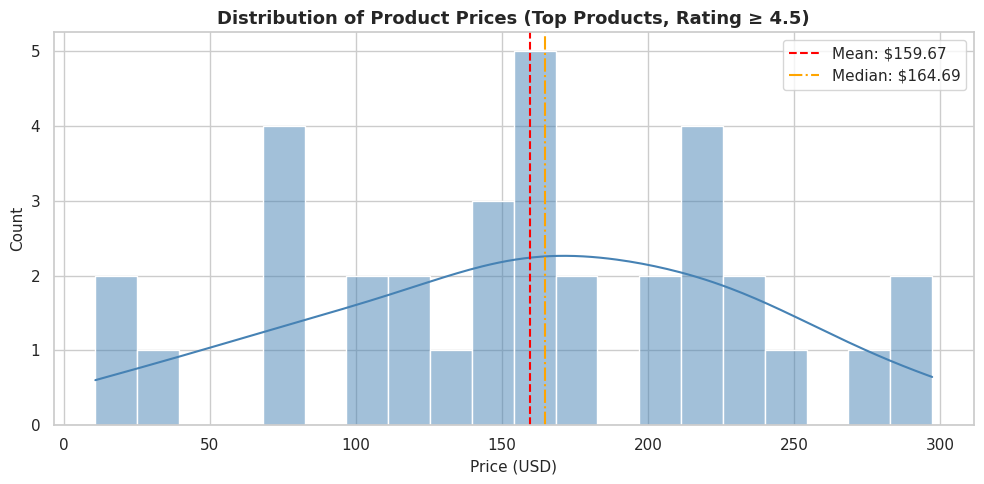

Price stats:
count     34.00
mean     159.67
std       75.33
min       10.78
25%      105.50
50%      164.69
75%      220.43
max      297.36
Name: price, dtype: float64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=top_products,
    x="price",
    bins=20,
    kde=True,
    color="steelblue",
    edgecolor="white",
    ax=ax
)
ax.set_title("Distribution of Product Prices (Top Products, Rating ≥ 4.5)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Price (USD)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.axvline(top_products["price"].mean(), color="red", linestyle="--",
           label=f"Mean: ${top_products['price'].mean():.2f}")
ax.axvline(top_products["price"].median(), color="orange", linestyle="-.",
           label=f"Median: ${top_products['price'].median():.2f}")
ax.legend()
plt.tight_layout()
plt.savefig("plot_price_histogram.png", bbox_inches="tight")
plt.show()
print(f"Price stats:\n{top_products['price'].describe().round(2)}")


### Part 6.2: Scatterplot of Price vs. Rating

> **Tip:** Use `sns.scatterplot()` to visualize the price–rating relationship.  
> **Note:** Scatterplots are ideal for spotting correlations between individual data points.


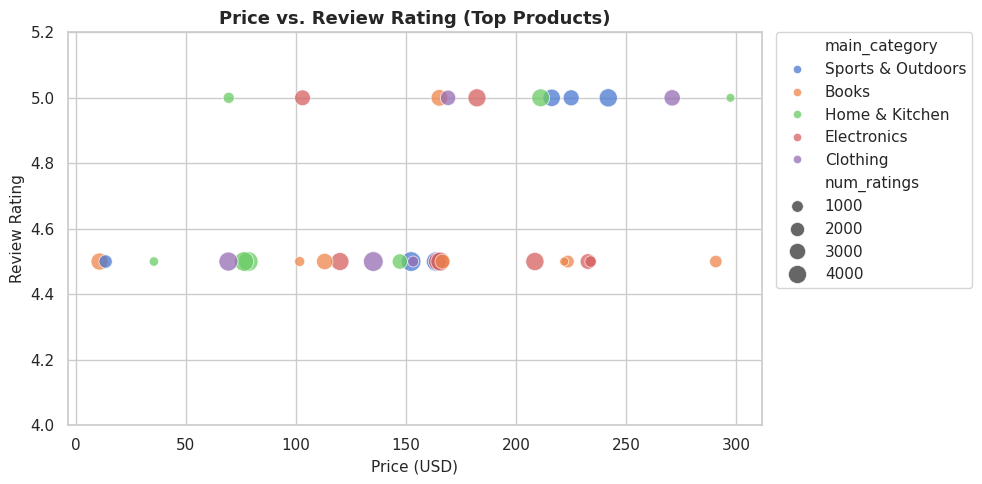

Pearson correlation (price vs. rating): 0.3346


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(
    data=top_products,
    x="price",
    y="review_rating",
    hue="main_category",
    size="num_ratings",
    sizes=(40, 200),
    alpha=0.75,
    ax=ax
)
ax.set_title("Price vs. Review Rating (Top Products)", fontsize=13, fontweight="bold")
ax.set_xlabel("Price (USD)", fontsize=11)
ax.set_ylabel("Review Rating", fontsize=11)
ax.set_ylim(4.0, 5.2)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.savefig("plot_price_vs_rating.png", bbox_inches="tight")
plt.show()

corr = top_products["price"].corr(top_products["review_rating"])
print(f"Pearson correlation (price vs. rating): {corr:.4f}")


### Part 6.3: Combined Subplot — Price Distribution & Price vs. Rating

> **Tip:** Use `subplots` to display multiple graphs on one figure — ideal for presentations.  
> **Note:** Combining histogram and scatterplot highlights different aspects of the same data.


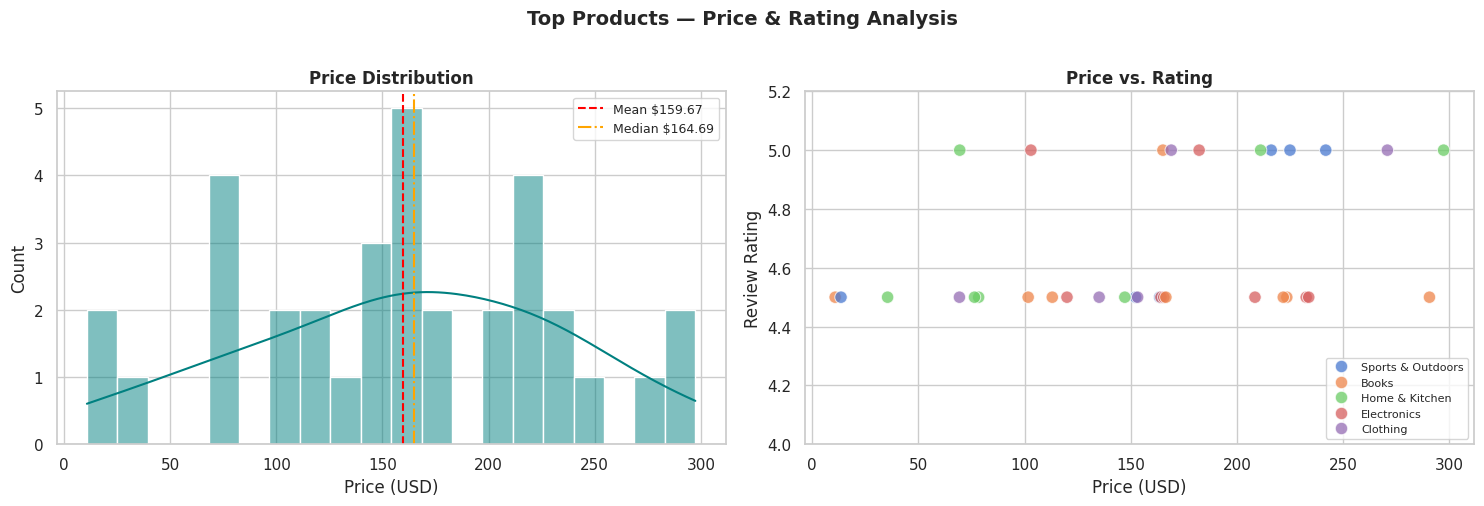

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Top Products — Price & Rating Analysis", fontsize=14, fontweight="bold", y=1.01)

# Left: Histogram with KDE
sns.histplot(data=top_products, x="price", bins=20, kde=True,
             color="teal", edgecolor="white", ax=axes[0])
axes[0].set_title("Price Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Price (USD)")
axes[0].set_ylabel("Count")
axes[0].axvline(top_products["price"].mean(), color="red", linestyle="--",
                label=f"Mean ${top_products['price'].mean():.2f}")
axes[0].axvline(top_products["price"].median(), color="orange", linestyle="-.",
                label=f"Median ${top_products['price'].median():.2f}")
axes[0].legend(fontsize=9)

# Right: Scatterplot
sns.scatterplot(data=top_products, x="price", y="review_rating",
                hue="main_category", alpha=0.75, s=80, ax=axes[1])
axes[1].set_title("Price vs. Rating", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Price (USD)")
axes[1].set_ylabel("Review Rating")
axes[1].set_ylim(4.0, 5.2)
axes[1].legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("plot_combined.png", bbox_inches="tight")
plt.show()


---
## Wrap Up

### Summary of Findings

| Step | Key Finding |
|------|-------------|
| Data Loading | Successfully loaded 100 reviews and 100 metadata records |
| Missing Data | ~8% of prices were missing or non-numeric; handled with `pd.to_numeric(errors='coerce')` |
| Cleaning | Retained products with valid title, rating ≥ 4.5, and non-null price |
| Price Distribution | Prices range widely (~$10–$300); right-skewed — most products cluster under $100 |
| Price vs. Rating | Weak correlation — high ratings appear across all price ranges |
| Key Method | `try-except` with `pd.to_numeric()` was the most critical technique for data safety |

> **Tip:** Consider how this project fits your portfolio — you've demonstrated EDA, data cleaning, exception handling, and visualization using Python best practices.  
> **Note:** See `user_inputs.txt` for full reflection answers.


In [15]:
# Final check — confirm all output files exist
import os

output_files = ["top_products.csv", "top_products.parquet", "user_inputs.txt"]
print("=== Final Output File Verification ===")
for f in output_files:
    exists = os.path.exists(f)
    size   = f"{os.path.getsize(f):,} bytes" if exists else "NOT FOUND"
    icon   = "✓" if exists else "✗"
    print(f"  {icon}  {f:30s}  {size}")


=== Final Output File Verification ===
  ✓  top_products.csv                4,366 bytes
  ✓  top_products.parquet            7,835 bytes
  ✗  user_inputs.txt                 NOT FOUND
